In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:
# upr 1

def r0(x, y):
    return max([abs(i - k) for i, k in zip(x, y)])

def r1(x, y):
    return sum([abs(i - k) for i, k in zip(x, y)])

def r2(x, y):
    return sum([(i - k)**2 for i, k in zip(x, y)])**0.5
    
    
o = [0, 0]
a1 = [3, 4]
b1 = [4, 3]
a2 = [1, 2, 3, 4]
b2 = [7, 3, 4, 200]

print('расстояние между O(0, 0) и A(3, 4):')
print('\t r0(x, y) =', r0(o, a1))
print('\t r1(x, y) =', r1(o, a1))
print('\t r2(x, y) =', r2(o, a1))
print('расстояние между O(0, 0) и B(4, 3):')
print('\t r0(x, y) =', r0(o, b1))
print('\t r1(x, y) =', r1(o, b1))
print('\t r2(x, y) =', r2(o, b1))
print('расстояние между A(1, 2, 3, 4) и B(7, 3, 4, 200):')
print('\t r0(x, y) =', r0(a2, b2))
print('\t r1(x, y) =', r1(a2, b2))
print('\t r2(x, y) =', r2(a2, b2))

расстояние между O(0, 0) и A(3, 4):
	 r0(x, y) = 4
	 r1(x, y) = 7
	 r2(x, y) = 5.0
расстояние между O(0, 0) и B(4, 3):
	 r0(x, y) = 4
	 r1(x, y) = 7
	 r2(x, y) = 5.0
расстояние между A(1, 2, 3, 4) и B(7, 3, 4, 200):
	 r0(x, y) = 196
	 r1(x, y) = 204
	 r2(x, y) = 196.0969148150985


In [39]:
# upr 2

def cset(x0, r, dist):
    x = np.linspace(x0[0] - r, x0[0] + r)
    y = np.linspace(x0[1] - r, x0[1] + r)
    dots = []
    for i in x:
        for k in y:
            if (dist(x0, [i, k]) <= r):
                dots.append((i, k))
    plt.plot([i[0] for i in dots], [i[1] for i in dots], 'o')

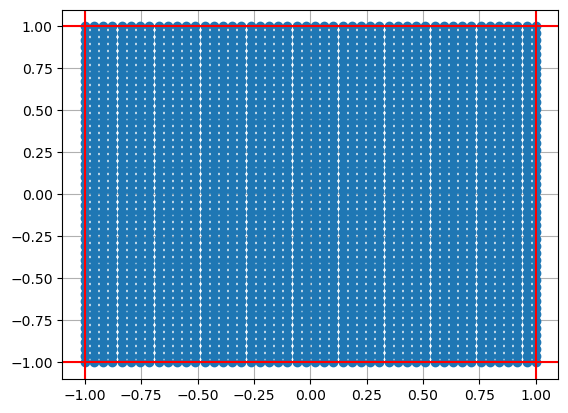

In [43]:
# r0 -- расстояние Чебышева

cset([0, 0], 1, r0)
plt.axvline(1, color='red')
plt.axvline(-1, color='red')
plt.axhline(1, color='red')
plt.axhline(-1, color='red')
plt.plot()
plt.grid()

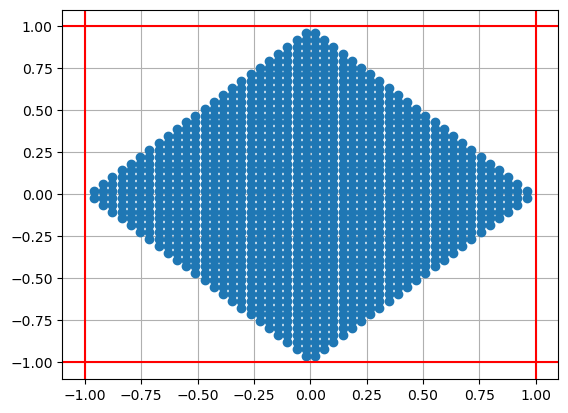

In [44]:
# r1 -- расстояние "городских кварталов"

cset([0, 0], 1, r1)
plt.axvline(1, color='red')
plt.axvline(-1, color='red')
plt.axhline(1, color='red')
plt.axhline(-1, color='red')
plt.plot()
plt.grid()

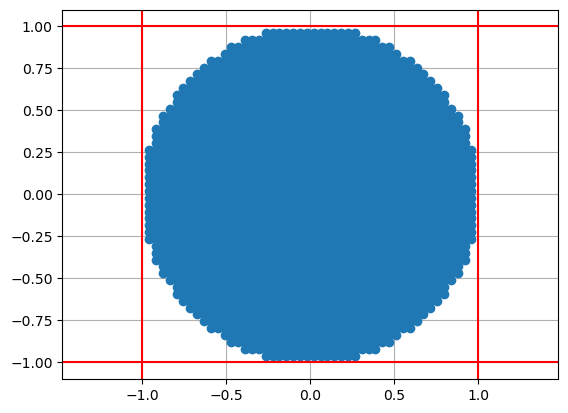

In [46]:
# r2 -- евклидово расстояние

cset([0, 0], 1, r2)
plt.axvline(1, color='red')
plt.axvline(-1, color='red')
plt.axhline(1, color='red')
plt.axhline(-1, color='red')
plt.axis('equal')
plt.plot()
plt.grid()

In [67]:
# upr 3

x10 = [3]

for i in range(9):
    x10.append(math.tan(x10[-1]))

print(*x10, sep='\n')

3
-0.1425465430742778
-0.14351994778492885
-0.14451354178374737
-0.14552803216462146
-0.14656416116305784
-0.14762270843290942
-0.14870449350594375
-0.1498103784518568
-0.15094127075832084


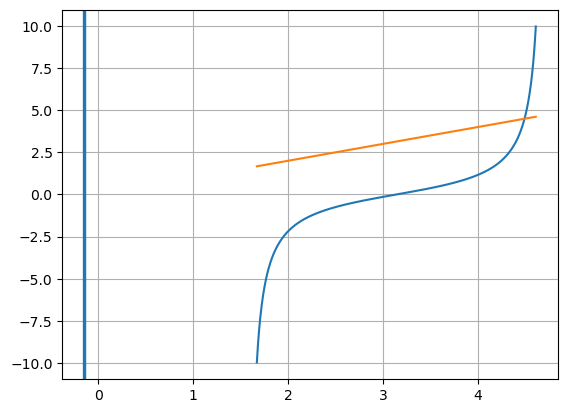

In [77]:
x = np.linspace(np.pi / 2 + 0.1, 3 * np.pi / 2 - 0.1, 1000)
plt.plot(x, np.tan(x))
plt.plot(x, x)
for i in x10[1::]:
    plt.axvline(i)
plt.grid()

In [124]:
# upr 4

def iterate(f, a, x1, eps):
    n = (math.log(eps * (1 - a)) - math.log(r1([x1], [f(x1)]))) / math.log(a)
    x = x1
    print(1, ':', x)
    for i in range(2, math.ceil(n) + 1):
        x = f(x)
        print(i, ':', x)
    return x

In [125]:
# primer 2

x0 = iterate(lambda x: math.atan(x) + math.pi, 0.2884, 3, 0.001)

1 : 3
2 : 4.3906384259880475
3 : 4.4884516448912075
4 : 4.4931752502709985
5 : 4.493398404996493
6 : 4.493408936315932
7 : 4.493409433294847


$$ 4x = \cos(x) $$
$$ x = \frac{\cos(x)}{4} = \varphi(x) $$
$$ \varphi'(x) = \frac{-\sin(x)}{4}$$ 
$$ \frac{|\sin(x)|}{4} < 1 $$
$$ |\sin(x)| < 4 $$  
Таким образом, итерационный процесс сходится для любого начального приближения  
Оценим производную сверху:  
$$ \frac{-\sin(x)}{4} < \frac{1}{4} = \alpha $$

In [137]:
# 4x = cos(x)

x0 = iterate(lambda x: math.cos(x) / 4, 0.25, 10, 0.0001)

1 : 10
2 : -0.2097678822691131
3 : 0.24451981890378968
4 : 0.24256342102148132
5 : 0.24268136305472676
6 : 0.24267427918980825
7 : 0.24267470475802352
8 : 0.2426746791920546
9 : 0.24267468072792892


In [238]:
# upr 5

def c_check(C):
    f1, f2, f3 = 0, 0, 0
    if (max([sum(C[i]) for i in range(C.shape[0])]) >= 1):
        f1 = 1
    if (max([sum(C.transpose()[i]) for i in range(C.shape[0])]) >= 1):
        f2 = 1
    s = 0
    for k in range(C.shape[0]):
        for j in range(C.shape[1]):
            s += C[k][j]**2
    if (s**0.5 >= 1):
        f3 = 1
    if (f1 or f2 or f3):
        print(f1, f2, f3)
    return 1
        

def iter_le(A, B, eps):
    C = -A + np.eye(A.shape[0])
    
    c_check(C)
    
    def f(x): # f(x) = x
        return B + (-A + np.eye(A.shape[0])) @ x
    
    n = 1
    x1 = B
    x2 = f(x1)
    diff = np.abs(x2 - x1)
    while (sum(diff) >= eps):
        # print(x2)
        x1 = x2
        x2 = f(x1)
        n += 1
        diff = np.abs(x2 - x1)
    print('число итераций:', n)
    return x2

In [257]:
A = np.array([[4.17, 0.31, -0.31], [0.13, 5.32, 0.41], [0.51, 0.4, 3.15]])
B = np.array([[5.34], [8.01], [6.12]])

A = A / np.max(A)
B = B / np.max(A)

x = iter_le(A, B, 0.001)
x

число итераций: 9


array([[6.89457424],
       [7.20152995],
       [8.30491279]])

In [258]:
np.linalg.inv(A) @ B

array([[6.89471802],
       [7.20145441],
       [8.30524192]])

In [254]:
x

array([[152.50238668],
       [228.7538268 ],
       [174.7766515 ]])

In [255]:
A = np.array([[4.17, 0.31, -0.31], [0.13, 5.32, 0.41], [0.51, 0.4, 3.15] ])
B = np.array([[5.34], [8.01], [6.12]])

np.linalg.inv(A) @ B

array([[1.29599963],
       [1.35365684],
       [1.5611357 ]])